In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import scipy.stats as stats

In [3]:
df=pd.read_csv(r"C:\Users\GR0012AU\Downloads\train.csv")

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df1=df[["Survived","Age","Fare"]]

In [6]:
df1

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [8]:
df1.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [9]:
df1["Age"]=df1["Age"].fillna(df["Age"].mean())

C:\Users\GR0012AU\AppData\Local\Temp\ipykernel_8060\2586842743.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Age"]=df1["Age"].fillna(df["Age"].mean())


In [10]:
df1.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

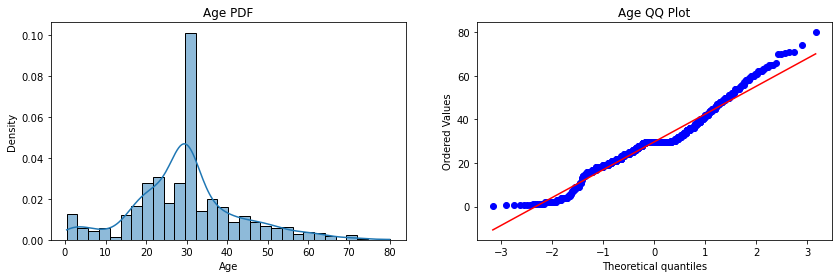

In [11]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(df1["Age"],stat="density",kde=True)
# sns.distplot(df1["Age"])
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(df1["Age"],dist="norm",plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train,x_test,y_train,y_test=train_test_split(df1.drop(columns=["Survived"],axis=1),df1["Survived"],test_size=0.3,random_state=0)

In [14]:
x_train

,Age,Fare
857,51.000000,26.5500
52,49.000000,76.7292
386,1.000000,46.9000
124,54.000000,77.2875
578,29.699118,14.4583
...,...,...
835,39.000000,83.1583
192,19.000000,7.8542
629,29.699118,7.7333
559,36.000000,17.4000


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [16]:
LogR=LogisticRegression()
DTCF=DecisionTreeClassifier()

In [17]:
LogR.fit(x_train,y_train)

LogisticRegression()

In [18]:
DTCF.fit(x_train,y_train)

DecisionTreeClassifier()

In [19]:
y_pred=LogR.predict(x_test)
y_predD=DTCF.predict(x_test)

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
acc_sc=accuracy_score(y_test,y_pred)

In [22]:
acc_sc1=accuracy_score(y_test,y_predD)

In [23]:
print(acc_sc)
print(acc_sc1)

0.6865671641791045
0.6604477611940298


In [24]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [25]:
trf=FunctionTransformer(func=np.log1p)

In [26]:
x_train_tranform=trf.fit_transform(x_train)
x_test_transform=trf.transform(x_test)

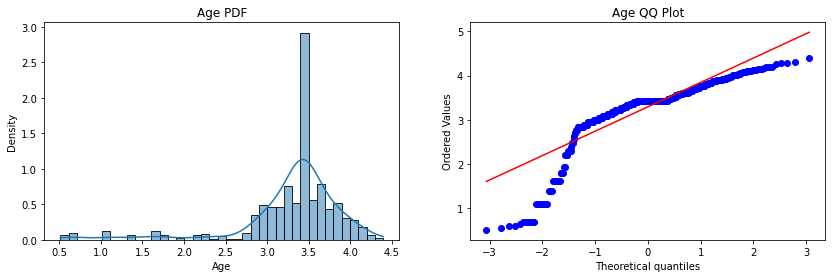

In [27]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(x_train_tranform["Age"],stat="density",kde=True)
# sns.distplot(df1["Age"])
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(x_train_tranform["Age"],dist="norm",plot=plt)
plt.title('Age QQ Plot')

plt.show()

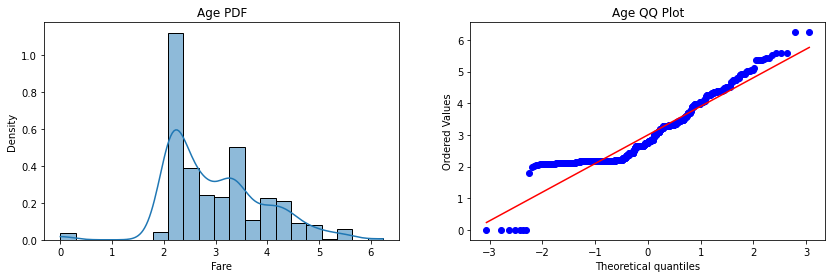

In [28]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(x_train_tranform["Fare"],stat="density",kde=True)
# sns.distplot(df1["Age"])
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(x_train_tranform["Fare"],dist="norm",plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [29]:
x_train_tranform

,Age,Fare
857,3.951244,3.316003
52,3.912023,4.353231
386,0.693147,3.869116
124,4.007333,4.360388
578,3.424234,2.738146
...,...,...
835,3.688879,4.432700
192,2.995732,2.180892
629,3.424234,2.167143
559,3.610918,2.912351


In [30]:
LogR.fit(x_train_tranform,y_train)
DTCF.fit(x_train_tranform,y_train)

DecisionTreeClassifier()

In [31]:
y_pred=LogR.predict(x_test_transform)
y_predD=DTCF.predict(x_test_transform)

In [32]:
acc_sc=accuracy_score(y_test,y_pred)
acc_sc1=accuracy_score(y_test,y_predD)
print(acc_sc)
print(acc_sc1)

0.7126865671641791
0.6828358208955224


In [33]:
x_train_Age=trf.fit_transform(x_train["Age"])

In [34]:
x_train_Age

857    3.951244
52     3.912023
386    0.693147
124    4.007333
578    3.424234
         ...   
835    3.688879
192    2.995732
629    3.424234
559    3.610918
684    4.110874
Name: Age, Length: 623, dtype: float64

In [35]:
x_train["Age"]=x_train_Age

In [36]:
x_train

,Age,Fare
857,3.951244,26.5500
52,3.912023,76.7292
386,0.693147,46.9000
124,4.007333,77.2875
578,3.424234,14.4583
...,...,...
835,3.688879,83.1583
192,2.995732,7.8542
629,3.424234,7.7333
559,3.610918,17.4000


In [37]:
x_test_Age=trf.transform(x_test["Age"])

In [38]:
x_test["Age"]=x_test_Age

In [39]:
x_test

,Age,Fare
495,3.424234,14.4583
648,3.424234,7.5500
278,2.079442,29.1250
31,3.424234,146.5208
255,3.401197,15.2458
...,...,...
263,3.713572,0.0000
718,3.424234,15.5000
620,3.332205,14.4542
786,2.944439,7.4958


In [40]:
LogR.fit(x_train,y_train)
DTCF.fit(x_train,y_train)

DecisionTreeClassifier()

In [41]:
y_pred=LogR.predict(x_test)
y_predD=DTCF.predict(x_test)

In [42]:
acc_sc=accuracy_score(y_test,y_pred)
acc_sc1=accuracy_score(y_test,y_predD)
print(acc_sc)
print(acc_sc1)

0.7238805970149254
0.6753731343283582


In [45]:
from sklearn.model_selection import cross_val_score

In [58]:
def apply_transform(transform):
    x=df1[["Age","Fare"]]
    y=df1["Survived"]
    trf=ColumnTransformer([("function",FunctionTransformer(transform),["Fare"])],remainder="passthrough")
    x_trans=trf.fit_transform(x)
    clf=LogisticRegression()
    print("Accuracy",np.mean(cross_val_score(clf,x_trans,y,scoring="accuracy",cv=10)))
    
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(x["Fare"],stat="density",kde=True)
    plt.subplot(1,2,2)
    stats.probplot(x["Fare"],dist="norm",plot=plt)
    
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(x_trans[:,0],stat="density",kde=True)
    plt.subplot(1,2,2)
    stats.probplot(x_trans[:,0],dist="norm",plot=plt)
    

Accuracy 0.6712609238451936


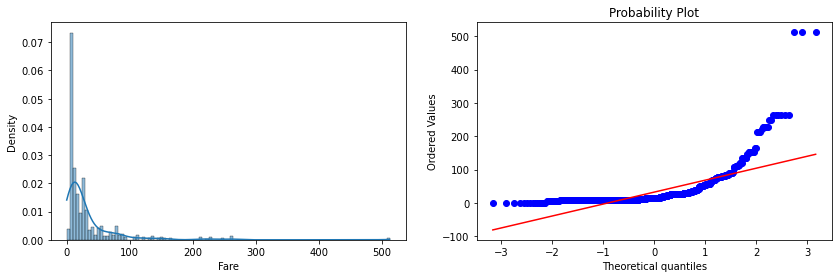

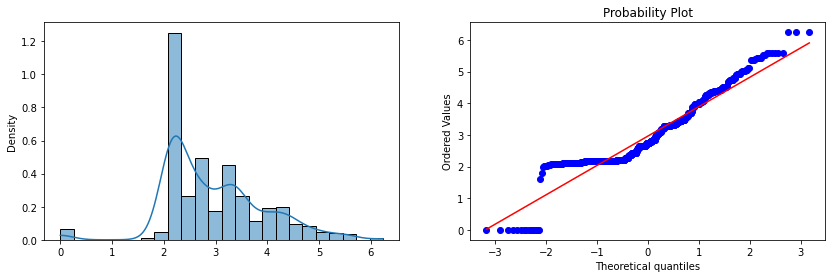

In [59]:
apply_transform(np.log1p)

Accuracy 0.6611485642946316


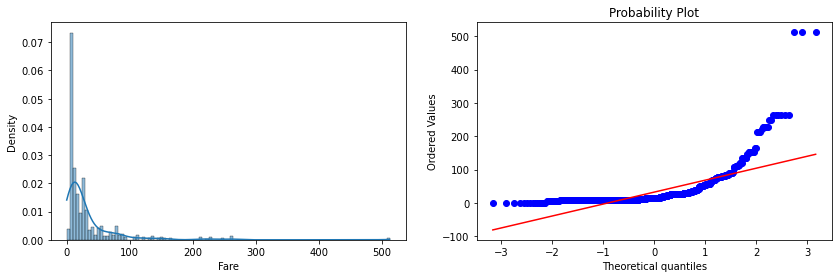

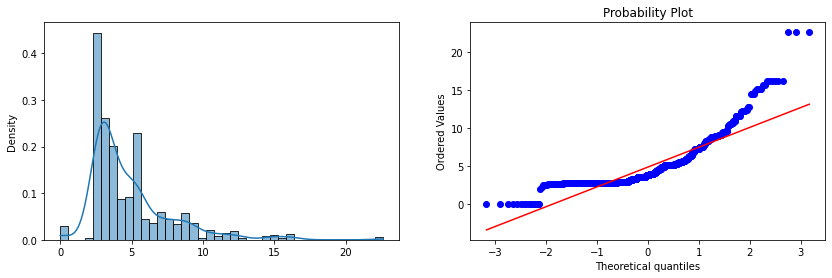

In [60]:
apply_transform(np.sqrt)

Accuracy 0.6195131086142323


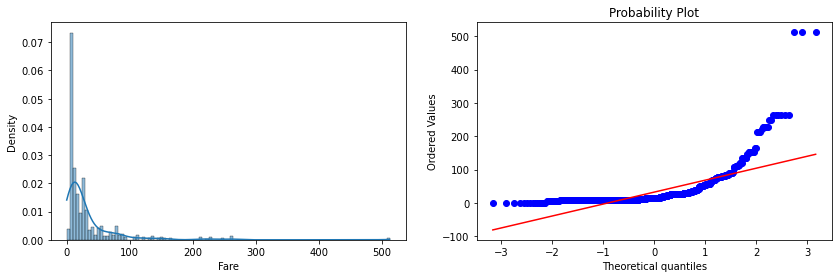

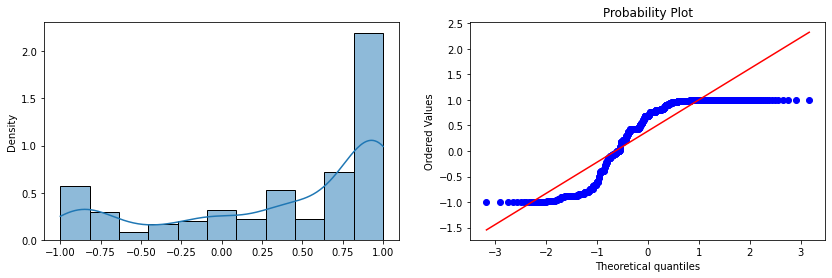

In [61]:
apply_transform(np.sin)

Accuracy 0.6442446941323345


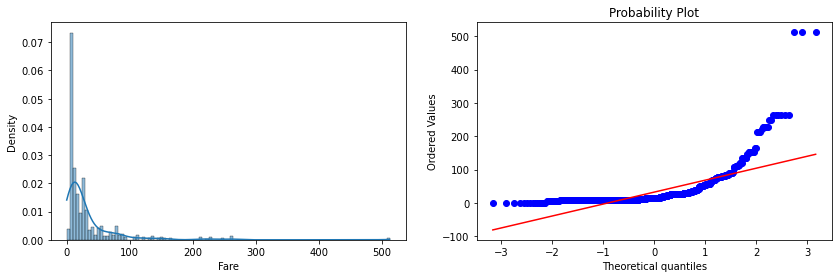

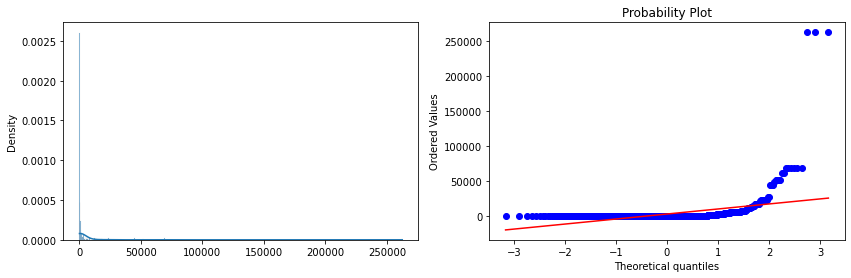

In [63]:
apply_transform(np.square)

In [56]:
def apply_transform(transform):
    x=df1[["Age","Fare"]]
    y=df1["Survived"]
    trf=ColumnTransformer([("function",FunctionTransformer(transform),["Age"])],remainder="passthrough")
    x_trans=trf.fit_transform(x)
    clf=LogisticRegression()
    print("Accuracy",np.mean(cross_val_score(clf,x_trans,y,scoring="accuracy",cv=10)))
    
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(x["Age"],stat="density",kde=True)
    plt.subplot(1,2,2)
    stats.probplot(x["Age"],dist="norm",plot=plt)
    
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(x_trans[:,0],stat="density",kde=True)
    plt.subplot(1,2,2)
    stats.probplot(x_trans[:,0],dist="norm",plot=plt)
    

Accuracy 0.6712484394506867


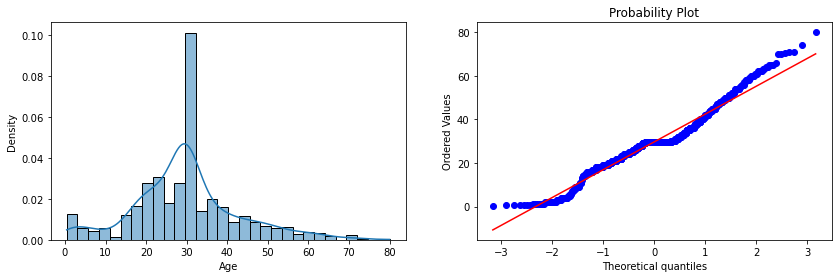

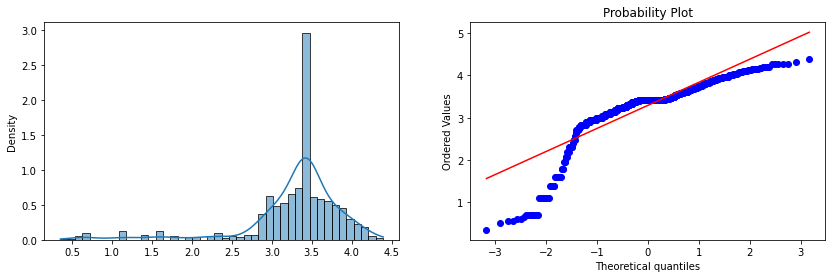

In [57]:
apply_transform(np.log1p)